# Projet NoSQL & Big Data - Films TMDB (Cassandra + Redis)
## 03. Rapport analytique

Ce notebook est indépendant des deux précédents (`01_exploration_nettoyage.ipynb`
et `02_modelisation_ingestion.ipynb`) — il suppose juste que les données sont déjà
en place dans Cassandra et Redis (ce qui est fait depuis le notebook 02).

Jusqu'ici, mes agrégations avaient été faites avec pandas (notebook 1) pour explorer
les données avant insertion. Cette fois, je répète les mêmes questions-métier mais
en interrogeant directement Cassandra et Redis en production — c'est la différence
entre "explorer" et "exploiter" les bases une fois qu'elles sont en place.

Je vais retomber sur des chiffres déjà vus dans le notebook 1 (normal, ce sont les
mêmes données), mais cette fois la source est la vraie base, pas le CSV brut.


## 0. Connexion aux bases

Comme ce notebook est ouvert indépendamment, je dois refaire la connexion à
Cassandra et Redis depuis zéro — les objets `session` et `redis_client` ne
sont pas partagés entre notebooks différents, chacun a sa propre mémoire.


In [9]:
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

load_dotenv()


True

In [10]:
from cassandra.cluster import Cluster, ProtocolVersion
from cassandra.auth import PlainTextAuthProvider

cloud_config = {"secure_connect_bundle": os.environ["ASTRA_DB_BUNDLE_PATH"], "connect_timeout": 30}
auth_provider = PlainTextAuthProvider(username="token", password=os.environ["ASTRA_DB_APPLICATION_TOKEN"])
cluster = Cluster(cloud=cloud_config, auth_provider=auth_provider, protocol_version=ProtocolVersion.V4)
session = cluster.connect()
session.set_keyspace("tmdb_platform")
print("Connectée à Cassandra, keyspace tmdb_platform sélectionné.")


Connectée à Cassandra, keyspace tmdb_platform sélectionné.


In [11]:
import redis

redis_client = redis.Redis(
    host=os.environ["REDIS_HOST"],
    port=int(os.environ["REDIS_PORT"]),
    password=os.environ["REDIS_PASSWORD"],
    username=os.environ.get("REDIS_USERNAME", "default"),
    decode_responses=True,
)
print("Connectée à Redis :", redis_client.ping())


Connectée à Redis : True


## 1. Quels sont les 10 films les mieux notés, tous genres confondus ?

Je vais chercher cette réponse dans **Redis**, pas Cassandra — c'est exactement
le cas d'usage pour lequel j'ai construit `leaderboard:top_rated` : un classement
déjà trié, récupérable en une seule commande quasi instantanée (`ZREVRANGE`),
alors qu'en Cassandra il aurait fallu scanner toute la table `movies_by_id`
triée manuellement côté Python.


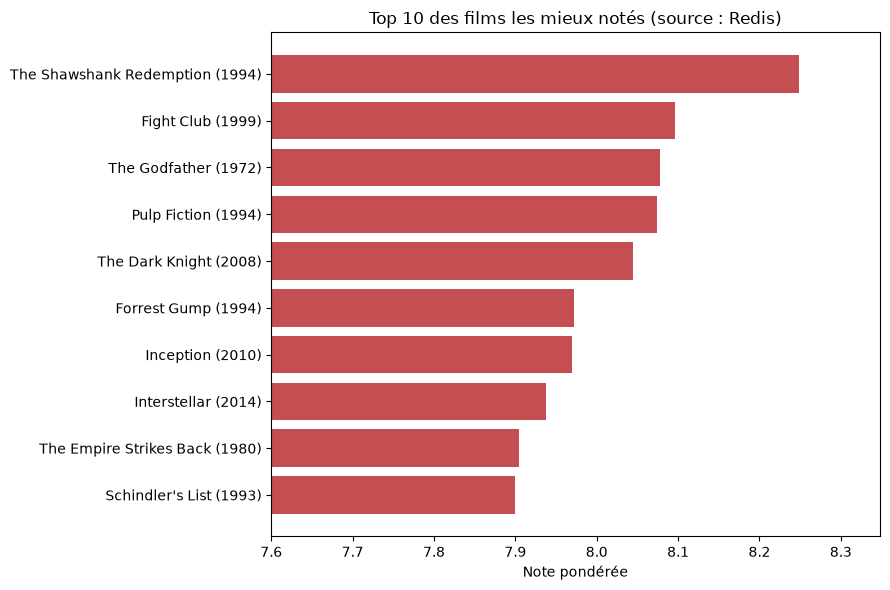

In [12]:
top10 = redis_client.zrevrange("leaderboard:top_rated", 0, 9, withscores=True)

titles, scores = [], []
for movie_id, score in top10:
    infos = redis_client.hgetall(f"movie:{movie_id}")
    titles.append(f"{infos['title']} ({infos['release_year']})")
    scores.append(score)

plt.figure(figsize=(9, 6))
plt.barh(titles[::-1], scores[::-1], color="#C44E52")
plt.xlabel("Note pondérée")
plt.title("Top 10 des films les mieux notés (source : Redis)")
plt.xlim(min(scores) - 0.3, max(scores) + 0.1)
plt.tight_layout()
plt.show()


## 2. Quels sont les films les mieux notés, par genre ?

Cette fois je vais chercher dans **Cassandra**, table `movies_by_genre`. Comme
cette table est partitionnée par `genre` et triée par `weighted_rating`
décroissant (clustering order), je n'ai qu'à filtrer sur le genre et prendre
les 5 premières lignes — aucun tri à refaire côté Python, Cassandra me les
rend déjà dans l'ordre.

**Une vraie limite à noter ici** : je ne peux interroger qu'**un genre à la
fois** (il faut connaître la valeur de la clé de partition). Impossible de
demander "le top 5 de chaque genre" en une seule requête comme le ferait un
`GROUP BY` en SQL — je dois boucler sur la liste des genres et faire une
requête par genre.


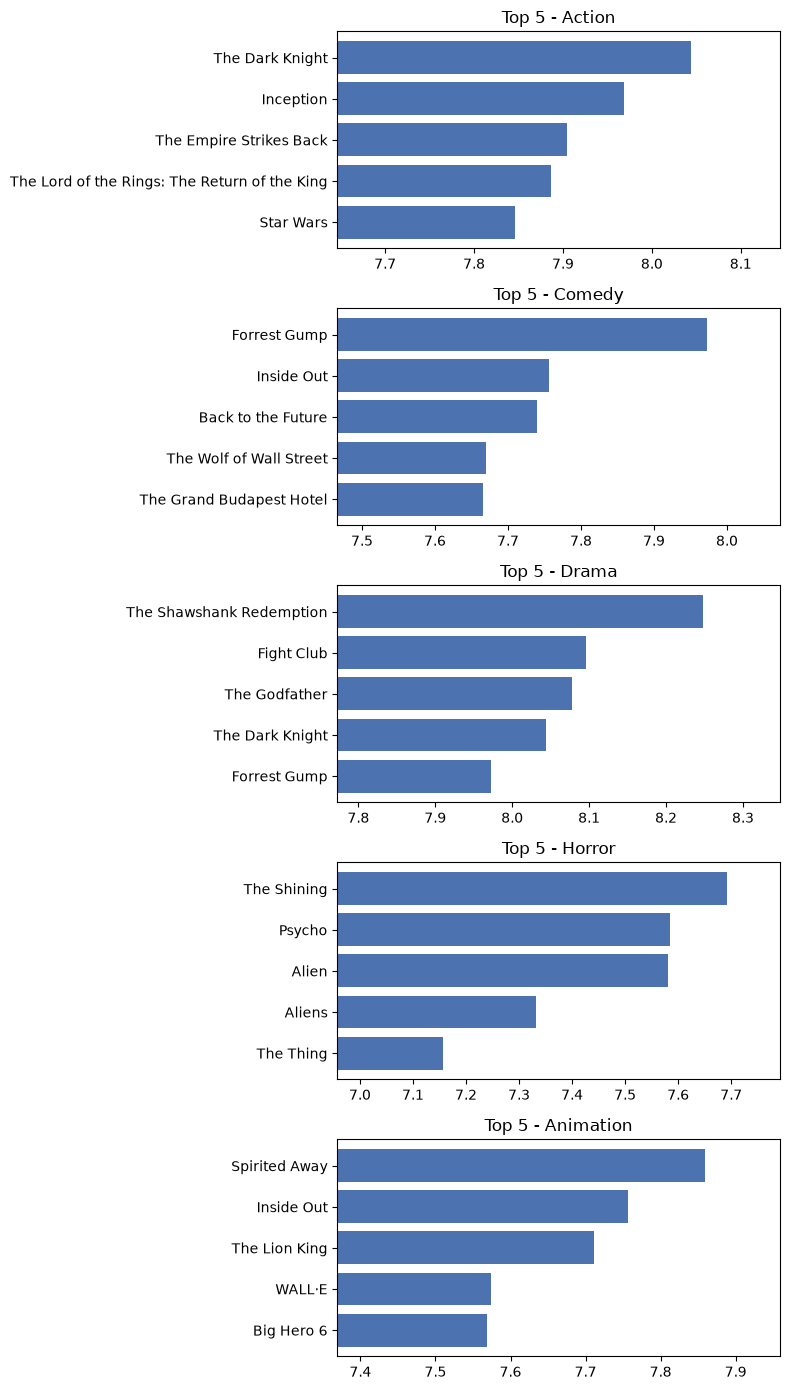

In [13]:
genres_a_comparer = ["Action", "Comedy", "Drama", "Horror", "Animation"]

fig, axes = plt.subplots(len(genres_a_comparer), 1, figsize=(8, 14))

for ax, genre in zip(axes, genres_a_comparer):
    rows = session.execute(
        "SELECT title, weighted_rating FROM movies_by_genre WHERE genre = %s LIMIT 5",
        (genre,)
    )
    rows = list(rows)
    titles = [r.title for r in rows][::-1]
    ratings = [r.weighted_rating for r in rows][::-1]

    ax.barh(titles, ratings, color="#4C72B0")
    ax.set_title(f"Top 5 - {genre}")
    ax.set_xlim(min(ratings) - 0.2, max(ratings) + 0.1)

plt.tight_layout()
plt.show()


## 3. Quels films a réalisés un metteur en scène donné ?

Requête sur `movies_by_director`, triée par année (clustering order DESC).
Je prends un réalisateur qui a plusieurs films dans le dataset (Steven
Spielberg, 27 films) pour que le résultat soit intéressant à lire.


In [14]:
realisateur = "Steven Spielberg"

rows = session.execute(
    "SELECT title, release_year, weighted_rating FROM movies_by_director WHERE director = %s",
    (realisateur,)
)
rows = list(rows)

print(f"{len(rows)} films de {realisateur} trouvés :")
for r in rows:  # déjà trié par release_year DESC grâce au clustering order de la table, pas besoin de re-trier
    print(f"  {r.release_year} - {r.title} (note : {r.weighted_rating:.2f})")

# Agrégation faite directement en CQL (AVG), pas en Python - possible ici sans ALLOW FILTERING
# puisque director est la clé de partition de movies_by_director.
avg_row = session.execute(
    "SELECT AVG(weighted_rating) AS avg_rating FROM movies_by_director WHERE director = %s",
    (realisateur,)
).one()
print(f"\nNote moyenne pondérée sur l'ensemble de sa filmographie ici présente : {avg_row.avg_rating:.2f}")


27 films de Steven Spielberg trouvés :
  2016 - The BFG (note : 6.05)
  2015 - Bridge of Spies (note : 6.90)
  2012 - Lincoln (note : 6.46)
  2011 - The Adventures of Tintin (note : 6.51)
  2011 - War Horse (note : 6.55)
  2008 - Indiana Jones and the Kingdom of the Crystal Skull (note : 5.81)
  2005 - War of the Worlds (note : 6.17)
  2005 - Munich (note : 6.43)
  2004 - The Terminal (note : 6.70)
  2002 - Minority Report (note : 6.83)
  2002 - Catch Me If You Can (note : 7.38)
  2001 - A.I. Artificial Intelligence (note : 6.57)
  1998 - Saving Private Ryan (note : 7.61)
  1997 - The Lost World: Jurassic Park (note : 6.17)
  1997 - Amistad (note : 6.27)
  1993 - Jurassic Park (note : 7.35)
  1993 - Schindler's List (note : 7.90)
  1991 - Hook (note : 6.40)
  1989 - Indiana Jones and the Last Crusade (note : 7.25)
  1985 - The Color Purple (note : 6.51)
  1984 - Indiana Jones and the Temple of Doom (note : 6.84)
  1983 - Twilight Zone: The Movie (note : 6.11)
  1982 - E.T. the Extra-Te

## 4. Comment évolue le nombre de films par année ?

Là, `movies_by_year` révèle une vraie contrainte structurelle de Cassandra :
`release_year` est la clé de partition. Pour compter les films année par
année sur une plage donnée, **je dois interroger chaque partition séparément**
— il n'existe pas de requête unique du type "COUNT(*) GROUP BY release_year"
qui parcourrait toutes les années en une fois. C'est le prix du modèle
dénormalisé orienté requêtes : rapide pour "une année précise", mais il faut
boucler pour une vue d'ensemble sur plusieurs années.


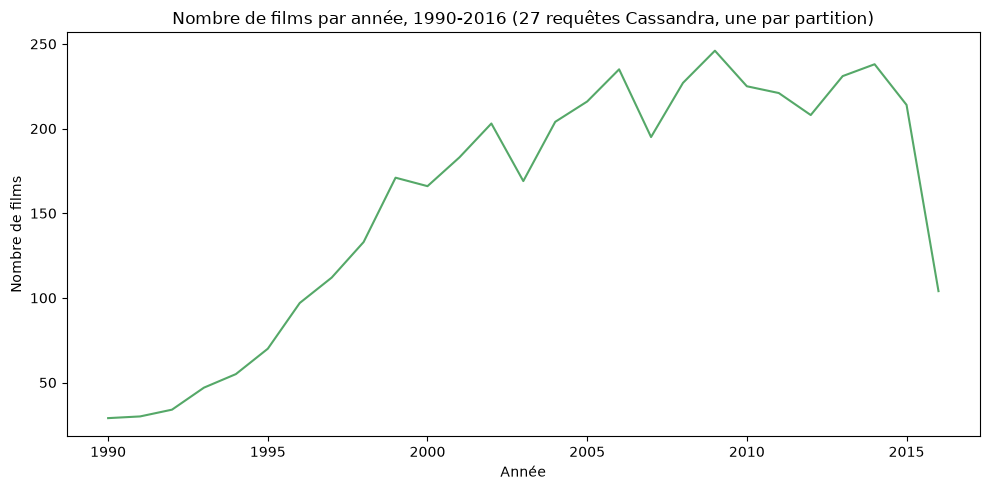

27 requêtes envoyées, une par année - chacune ne coûte qu'un accès à une seule partition.


In [15]:
annees = range(1990, 2017)
counts_par_annee = {}

for annee in annees:
    result = session.execute(
        "SELECT COUNT(*) FROM movies_by_year WHERE release_year = %s",
        (annee,)
    ).one()
    counts_par_annee[annee] = result.count

plt.figure(figsize=(10, 5))
plt.plot(list(counts_par_annee.keys()), list(counts_par_annee.values()), color="#55A868")
plt.xlabel("Année")
plt.ylabel("Nombre de films")
plt.title("Nombre de films par année, 1990-2016 (27 requêtes Cassandra, une par partition)")
plt.tight_layout()
plt.show()

print(f"{len(annees)} requêtes envoyées, une par année - chacune ne coûte qu'un accès à une seule partition.")


## 5. Dans quels films a joué tel acteur ?

Dernière question, sur `movies_by_actor`. Samuel L. Jackson apparaît dans le
top 5 du casting de 44 films du dataset — un bon exemple pour illustrer.


In [16]:
acteur = "Samuel L. Jackson"

rows = session.execute(
    "SELECT title, release_year FROM movies_by_actor WHERE actor_name = %s",
    (acteur,)
)
rows = list(rows)

print(f"{len(rows)} films trouvés avec {acteur} dans le top 5 du casting :")
for r in sorted(rows, key=lambda r: r.release_year or 0, reverse=True):
    print(f"  {r.release_year} - {r.title}")


44 films trouvés avec Samuel L. Jackson dans le top 5 du casting :
  2016 - The Legend of Tarzan
  2015 - The Hateful Eight
  2014 - Captain America: The Winter Soldier
  2013 - Turbo
  2012 - Django Unchained
  2012 - Zambezia
  2010 - The Other Guys
  2009 - Mother and Child
  2008 - Jumper
  2008 - The Spirit
  2008 - Lakeview Terrace
  2008 - Soul Men
  2007 - 1408
  2007 - Resurrecting the Champ
  2006 - Snakes on a Plane
  2006 - Black Snake Moan
  2006 - Farce of the Penguins
  2005 - Star Wars: Episode III - Revenge of the Sith
  2005 - Coach Carter
  2005 - The Man
  2005 - xXx: State of the Union
  2004 - The Incredibles
  2003 - S.W.A.T.
  2003 - Basic
  2002 - Changing Lanes
  2002 - Star Wars: Episode II - Attack of the Clones
  2002 - xXx
  2001 - The 51st State
  2001 - The Caveman's Valentine
  2000 - Shaft
  2000 - Unbreakable
  1999 - Deep Blue Sea
  1998 - The Negotiator
  1998 - Sphere
  1997 - Jackie Brown
  1997 - Eve's Bayou
  1996 - A Time to Kill
  1996 - The L

## Bilan du rapport analytique

- Redis a répondu à la question de classement global en une seule commande
  quasi instantanée (`ZREVRANGE`) — exactement son cas d'usage.
- Cassandra a bien répondu aux questions "filtrées sur une clé connue"
  (genre, réalisateur), avec un résultat déjà trié grâce au clustering
  order choisi lors de la modélisation (`weighted_rating DESC` pour le genre,
  `release_year DESC` pour le réalisateur) — pas de tri à refaire côté Python
  pour ces deux-là.
- Pour l'acteur en revanche, `movies_by_actor` n'a volontairement pas de
  clustering order utile ici (seulement `movie_id` par défaut) : le tri par
  année (question 5) est fait côté Python — preuve que le clustering order
  n'est un raccourci que quand on l'a explicitement prévu à la modélisation,
  pas un acquis automatique de Cassandra.
- La question 4 illustre une vraie limite : sans connaître à l'avance
  la valeur de la clé de partition qu'on veut lire, il n'y a pas de moyen
  d'agréger "toutes les années" en une seule requête — il faut boucler.
  C'est le compromis du query-first design, à l'opposé de SQL où un
  `GROUP BY release_year` unique aurait suffi.

Prochaine section : les scripts d'administration (dump, restauration, import
de fichiers volumineux, sécurisation).
